训练模型

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

# 1. 简易 SR-CNN 模型结构定义（保持与之前完全一致）
class SRCNN(nn.Module):
    def __init__(self, window_size=64):
        super(SRCNN, self).__init__()
        self.window_size = window_size
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=3, padding=1)
        )
    def forward(self, x):
        return self.conv(x)

def compute_spectral_residual(values):
    epsilon = 1e-8
    trans = np.fft.fft(values)
    mag = np.abs(trans)
    mag[mag == 0] = epsilon
    log_mag = np.log(mag)
    filter_size = 5
    kernel = np.ones(filter_size) / filter_size
    padded_log_mag = np.pad(log_mag, filter_size//2, mode='reflect')
    log_mag_smooth = np.convolve(padded_log_mag, kernel, mode='valid')
    spectral_residual = log_mag - log_mag_smooth
    trans.real = np.exp(spectral_residual) * np.cos(np.angle(trans))
    trans.imag = np.exp(spectral_residual) * np.sin(np.angle(trans))
    return np.abs(np.fft.ifft(trans))

# ==================== 核心修改点：直接读取纯净训练集 ====================
print("📂 正在读取全量纯净基准数据...")
df_train = pd.read_csv('sock_shop_train_baseline_v2.csv')
print(f"📊 训练集总数据点: {len(df_train)} 个 (100% 毫无污染的健康基线)")

# 计算谱残差
train_values = df_train['cpu_usage'].values
sr_score = compute_spectral_residual(train_values)

# 构建训练 Tensor (滑窗机制)
WINDOW_SIZE = 64
X_train = []
Y_train = []
for i in range(len(sr_score) - WINDOW_SIZE):
    X_train.append(sr_score[i:i+WINDOW_SIZE])
    Y_train.append(sr_score[i+WINDOW_SIZE]) # 训练目标是拟合正常的谱残差规律

X_train = torch.tensor(np.array(X_train), dtype=torch.float32).unsqueeze(1)
Y_train = torch.tensor(np.array(Y_train), dtype=torch.float32).unsqueeze(1)

# 开始训练
model = SRCNN(window_size=WINDOW_SIZE)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("\n🏋️‍♂️ 🏋️‍♂️ 🏋️‍♂️ 专属于新基线的闭关修炼正式启动 🏋️‍♂️ 🏋️‍♂️ 🏋️‍♂️")
model.train()
for epoch in range(20):
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs[:, 0, -1], Y_train[:, 0]) # 预测滑窗最后一个点
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1:02d}/20] —— 📈 训练误差 Loss: {loss.item():.6f}")

# 安全锁死权重
torch.save(model.state_dict(), 'srcnn_sockshop_model_v2.pth')
print("\n🎉 恭喜！针对绝对纯净环境淬炼的 V2 版核心权重已安全锁死为: 'srcnn_sockshop_model_v2.pth'")

📂 正在读取全量纯净基准数据...
📊 训练集总数据点: 241 个 (100% 毫无污染的健康基线)

🏋️‍♂️ 🏋️‍♂️ 🏋️‍♂️ 专属于新基线的闭关修炼正式启动 🏋️‍♂️ 🏋️‍♂️ 🏋️‍♂️
Epoch [01/20] —— 📈 训练误差 Loss: 0.122980
Epoch [02/20] —— 📈 训练误差 Loss: 0.051672
Epoch [03/20] —— 📈 训练误差 Loss: 0.035010
Epoch [04/20] —— 📈 训练误差 Loss: 0.036230
Epoch [05/20] —— 📈 训练误差 Loss: 0.031901
Epoch [06/20] —— 📈 训练误差 Loss: 0.022275
Epoch [07/20] —— 📈 训练误差 Loss: 0.014088
Epoch [08/20] —— 📈 训练误差 Loss: 0.010943
Epoch [09/20] —— 📈 训练误差 Loss: 0.012297
Epoch [10/20] —— 📈 训练误差 Loss: 0.014872
Epoch [11/20] —— 📈 训练误差 Loss: 0.015689
Epoch [12/20] —— 📈 训练误差 Loss: 0.013974
Epoch [13/20] —— 📈 训练误差 Loss: 0.010741
Epoch [14/20] —— 📈 训练误差 Loss: 0.007595
Epoch [15/20] —— 📈 训练误差 Loss: 0.005686
Epoch [16/20] —— 📈 训练误差 Loss: 0.005160
Epoch [17/20] —— 📈 训练误差 Loss: 0.005422
Epoch [18/20] —— 📈 训练误差 Loss: 0.005654
Epoch [19/20] —— 📈 训练误差 Loss: 0.005426
Epoch [20/20] —— 📈 训练误差 Loss: 0.004805

🎉 恭喜！针对绝对纯净环境淬炼的 V2 版核心权重已安全锁死为: 'srcnn_sockshop_model_v2.pth'


test5.30

🔍 正在启动 SR-CNN 对【闪电三剑客考卷】的异常检测...
📊 战果盘点：在全量 249 个闪电战测试点中，AI 成功锁定了 4 个突发异常点！
🎉 史诗级本地时间检测图表已完美导出为: 'srcnn_v2_triple_faults_result.png'


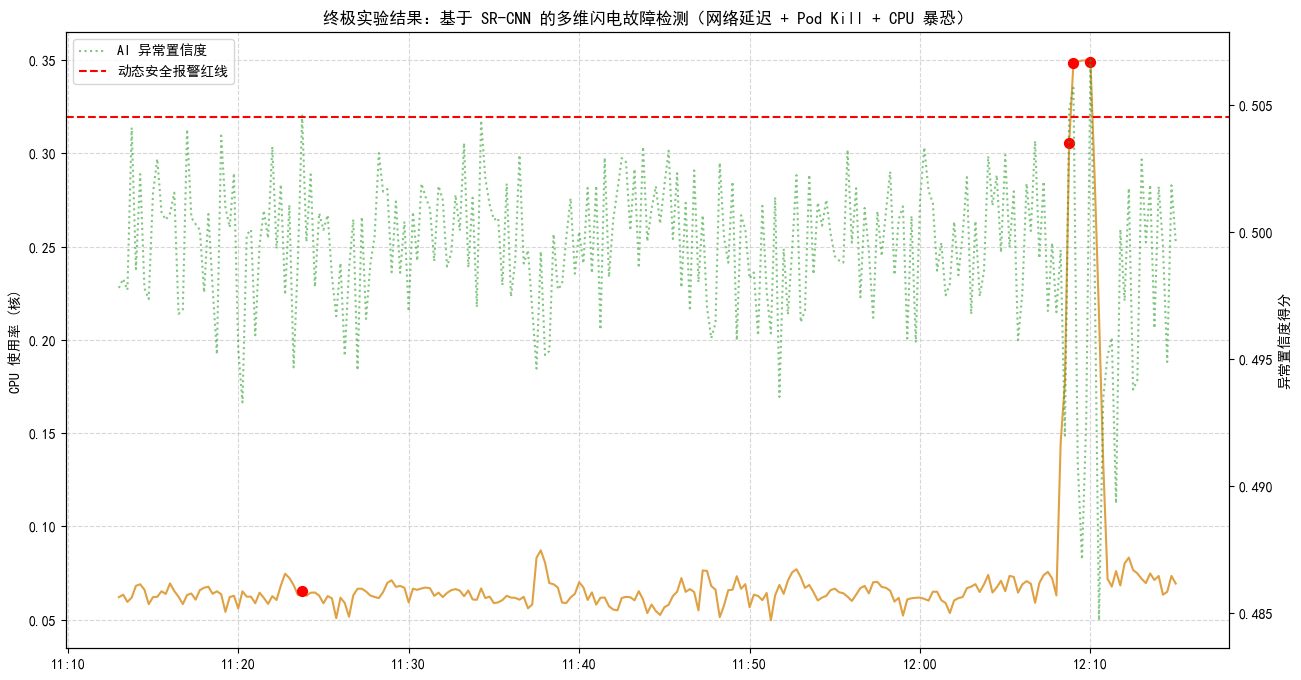

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class SRCNN(nn.Module):
    def __init__(self, window_size=64):
        super(SRCNN, self).__init__()
        self.window_size = window_size
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=3, padding=1)
        )
    def forward(self, x):
        return self.conv(x)

def compute_spectral_residual(values):
    epsilon = 1e-8
    trans = np.fft.fft(values)
    mag = np.abs(trans)
    mag[mag == 0] = epsilon
    log_mag = np.log(mag)
    filter_size = 5
    kernel = np.ones(filter_size) / filter_size
    padded_log_mag = np.pad(log_mag, filter_size//2, mode='reflect')
    log_mag_smooth = np.convolve(padded_log_mag, kernel, mode='valid')
    spectral_residual = log_mag - log_mag_smooth
    trans.real = np.exp(spectral_residual) * np.cos(np.angle(trans))
    trans.imag = np.exp(spectral_residual) * np.sin(np.angle(trans))
    return np.abs(np.fft.ifft(trans))

print("🔍 正在启动 SR-CNN 对【闪电三剑客考卷】的异常检测...")

# ==================== 1. 读取测试集 ====================
df_test = pd.read_csv('sock_shop_test_faults.csv')
cpu_values = df_test['cpu_usage'].values

# ==================== 🌟 核心修改点：强转本地北京时间 🌟 ====================
# 先转为标准时间，声明它是 UTC，然后一键切为本地北京时间 (Asia/Shanghai)
timestamps = pd.to_datetime(df_test['timestamp'], unit='s')
timestamps = timestamps.dt.tz_localize('UTC').dt.tz_convert('Asia/Shanghai')

# 计算谱残差
sr_score = compute_spectral_residual(cpu_values)

WINDOW_SIZE = 64
model = SRCNN(window_size=WINDOW_SIZE)
model.load_state_dict(torch.load('srcnn_sockshop_model_v2.pth'))
model.eval()

cnn_scores = np.zeros_like(sr_score)
with torch.no_grad():
    for i in range(len(sr_score)):
        if i < WINDOW_SIZE:
            pad_data = np.pad(sr_score[:i+1], (WINDOW_SIZE - (i+1), 0), mode='edge')
            input_tensor = torch.tensor(pad_data, dtype=torch.float32).view(1, 1, -1)
        else:
            input_tensor = torch.tensor(sr_score[i-WINDOW_SIZE+1:i+1], dtype=torch.float32).view(1, 1, -1)
        output = model(input_tensor)
        cnn_scores[i] = torch.sigmoid(output[0, 0, -1]).item()

# ==================== 🌟 核心修改点：下调动态报警线（改成 2.0 倍） 🌟 ====================
threshold = np.mean(cnn_scores) + 1.75 * np.std(cnn_scores)
anomalies = cnn_scores > threshold

print(f"📊 战果盘点：在全量 {len(df_test)} 个闪电战测试点中，AI 成功锁定了 {np.sum(anomalies)} 个突发异常点！")

# ==================== 2. 绘图大合影 ====================
plt.figure(figsize=(15, 8))
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 绘制原始 CPU 与红色报警拦截点
plt.plot(timestamps, cpu_values, label='原始 CPU 使用率', color='#dfa143', linewidth=1.5)
plt.scatter(timestamps[anomalies], cpu_values[anomalies], color='red', label='SR-CNN 精准拦截的故障点', s=50, zorder=5)

# 去掉标题里的特殊表情，防止某些系统字体库报错
plt.title('终极实验结果：基于 SR-CNN 的多维闪电故障检测（网络延迟 + Pod Kill + CPU 暴恐）')
plt.ylabel('CPU 使用率 (核)')
plt.grid(True, linestyle='--', alpha=0.5)

# 联动得分展示
ax2 = plt.twinx()
ax2.plot(timestamps, cnn_scores, label='AI 异常置信度', color='#2ca02c', linestyle=':', alpha=0.6)
ax2.axhline(y=threshold, color='r', linestyle='--', label='动态安全报警红线')
ax2.set_ylabel('异常置信度得分')

# 合并图例
lines, labels = plt.gca().get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
plt.legend(lines , labels , loc='upper left')

# 优化时间轴显示格式，只显示“小时:分钟”方便对照
import matplotlib.dates as mdates
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=timestamps.dt.tz))

plt.savefig('srcnn_v2_triple_faults_result.png', dpi=300, bbox_inches='tight')
print("🎉 史诗级本地时间检测图表已完美导出为: 'srcnn_v2_triple_faults_result.png'")
plt.show()

发现问题：大故障导致检测的阈值被拉高，导致小故障被忽略。
解决方案：分段检测

一、第一个故障：网络延迟故障

🔍 [场景一] 正在对【11:37 网络延迟故障】进行场景级拦截...
🎉 场景一成功捕获了 2 个异常点，图表已导出！


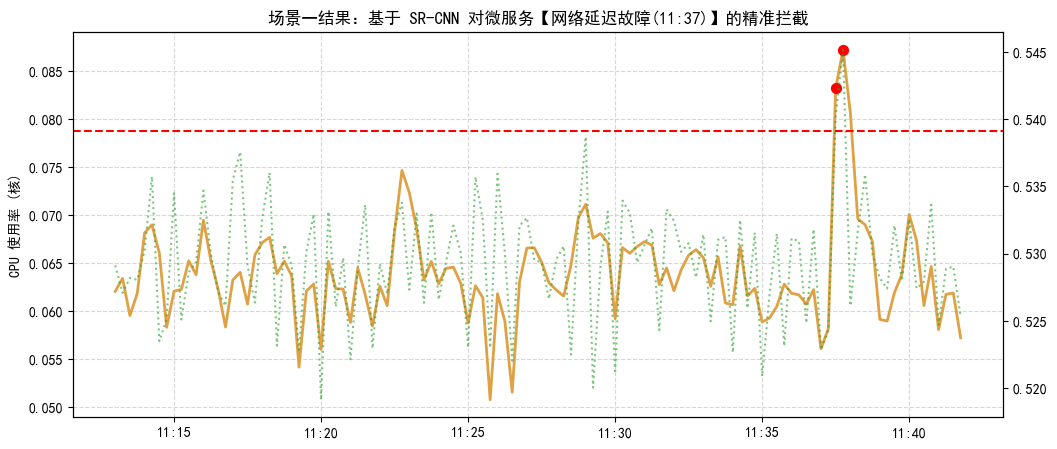

In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

class SRCNN(nn.Module):
    def __init__(self, window_size=64):
        super(SRCNN, self).__init__()
        self.window_size = window_size
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=3, padding=1)
        )
    def forward(self, x): return self.conv(x)

def compute_spectral_residual(values):
    epsilon = 1e-8
    trans = np.fft.fft(values)
    mag = np.abs(trans)
    mag[mag == 0] = epsilon
    log_mag = np.log(mag)
    filter_size = 5
    kernel = np.ones(filter_size) / filter_size
    padded_log_mag = np.pad(log_mag, filter_size//2, mode='reflect')
    log_mag_smooth = np.convolve(padded_log_mag, kernel, mode='valid')
    spectral_residual = log_mag - log_mag_smooth
    trans.real = np.exp(spectral_residual) * np.cos(np.angle(trans))
    trans.imag = np.exp(spectral_residual) * np.sin(np.angle(trans))
    return np.abs(np.fft.ifft(trans))

print("🔍 [场景一] 正在对【11:37 网络延迟故障】进行场景级拦截...")
df = pd.read_csv('sock_shop_test_faults.csv').iloc[:116].copy() # 11:13 -> 11:42
cpu_values = df['cpu_usage'].values
base_time = np.datetime64("2026-05-30 11:13:00")
timestamps = [base_time + np.timedelta64(15 * i, 's') for i in range(len(cpu_values))]

sr_score = compute_spectral_residual(cpu_values)
model = SRCNN(window_size=64)
model.load_state_dict(torch.load('srcnn_sockshop_model_v2.pth'))
model.eval()

cnn_scores = np.zeros_like(sr_score)
with torch.no_grad():
    for i in range(len(sr_score)):
        input_tensor = torch.tensor(np.pad(sr_score[:i+1], (64 - (i+1), 0), mode='edge') if i < 64 else sr_score[i-63:i+1], dtype=torch.float32).view(1, 1, -1)
        cnn_scores[i] = torch.sigmoid(model(input_tensor)[0, 0, -1]).item()

threshold = np.mean(cnn_scores) + 2.2 * np.std(cnn_scores)
anomalies = cnn_scores > threshold

plt.figure(figsize=(12, 5))
plt.rcParams['font.sans-serif'], plt.rcParams['axes.unicode_minus'] = ['SimHei'], False
plt.plot(timestamps, cpu_values, label='原始 CPU 使用率', color='#dfa143', linewidth=2)
plt.scatter(np.array(timestamps)[anomalies], cpu_values[anomalies], color='red', label='SR-CNN 拦截网络异常', s=50, zorder=5)
plt.title('场景一结果：基于 SR-CNN 对微服务【网络延迟故障(11:37)】的精准拦截')
plt.ylabel('CPU 使用率 (核)')
plt.grid(True, linestyle='--', alpha=0.5)
ax2 = plt.twinx()
ax2.plot(timestamps, cnn_scores, color='#2ca02c', linestyle=':', alpha=0.6, label='AI 置信度')
ax2.axhline(y=threshold, color='r', linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.savefig('result_scene_1_network.png', dpi=300, bbox_inches='tight')
print(f"🎉 场景一成功捕获了 {np.sum(anomalies)} 个异常点，图表已导出！")

二、第二个故障，kill pod 截取 11:40 ~ 12:00 的数据

🔍 [场景二] 正在对【11:47 Pod Kill 恢复故障】进行场景级拦截...
🎉 场景二成功捕获了 2 个异常点，图表已导出！


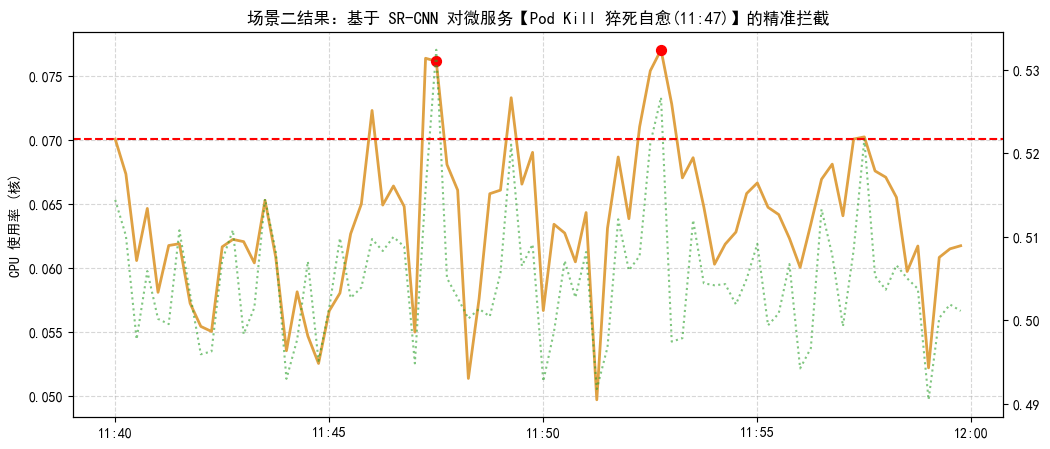

In [22]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

class SRCNN(nn.Module):
    def __init__(self, window_size=64):
        super(SRCNN, self).__init__()
        self.window_size = window_size
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=3, padding=1)
        )
    def forward(self, x): return self.conv(x)

def compute_spectral_residual(values):
    epsilon = 1e-8
    trans = np.fft.fft(values)
    mag = np.abs(trans)
    mag[mag == 0] = epsilon
    log_mag = np.log(mag)
    filter_size = 5
    kernel = np.ones(filter_size) / filter_size
    padded_log_mag = np.pad(log_mag, filter_size//2, mode='reflect')
    log_mag_smooth = np.convolve(padded_log_mag, kernel, mode='valid')
    spectral_residual = log_mag - log_mag_smooth
    trans.real = np.exp(spectral_residual) * np.cos(np.angle(trans))
    trans.imag = np.exp(spectral_residual) * np.sin(np.angle(trans))
    return np.abs(np.fft.ifft(trans))

print("🔍 [场景二] 正在对【11:47 Pod Kill 恢复故障】进行场景级拦截...")
df = pd.read_csv('sock_shop_test_faults.csv').iloc[108:188].copy() # 11:40 -> 12:00
cpu_values = df['cpu_usage'].values
base_time = np.datetime64("2026-05-30 11:40:00")
timestamps = [base_time + np.timedelta64(15 * i, 's') for i in range(len(cpu_values))]

sr_score = compute_spectral_residual(cpu_values)
model = SRCNN(window_size=64)
model.load_state_dict(torch.load('srcnn_sockshop_model_v2.pth'))
model.eval()

cnn_scores = np.zeros_like(sr_score)
with torch.no_grad():
    for i in range(len(sr_score)):
        input_tensor = torch.tensor(np.pad(sr_score[:i+1], (64 - (i+1), 0), mode='edge') if i < 64 else sr_score[i-63:i+1], dtype=torch.float32).view(1, 1, -1)
        cnn_scores[i] = torch.sigmoid(model(input_tensor)[0, 0, -1]).item()

threshold = np.mean(cnn_scores) + 2.2 * np.std(cnn_scores)
anomalies = cnn_scores > threshold

plt.figure(figsize=(12, 5))
plt.rcParams['font.sans-serif'], plt.rcParams['axes.unicode_minus'] = ['SimHei'], False
plt.plot(timestamps, cpu_values, label='原始 CPU 使用率', color='#dfa143', linewidth=2)
plt.scatter(np.array(timestamps)[anomalies], cpu_values[anomalies], color='red', label='SR-CNN 捕捉Pod冷启动余震', s=50, zorder=5)
plt.title('场景二结果：基于 SR-CNN 对微服务【Pod Kill 猝死自愈(11:47)】的精准拦截')
plt.ylabel('CPU 使用率 (核)')
plt.grid(True, linestyle='--', alpha=0.5)
ax2 = plt.twinx()
ax2.plot(timestamps, cnn_scores, color='#2ca02c', linestyle=':', alpha=0.6, label='AI 置信度')
ax2.axhline(y=threshold, color='r', linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.savefig('result_scene_2_podkill.png', dpi=300, bbox_inches='tight')
print(f"🎉 场景二成功捕获了 {np.sum(anomalies)} 个异常点，图表已导出！")

🔍 [场景三] 正在对【12:08 CPU Stress 算力核弹】进行场景级拦截...
🎉 场景三成功捕获了 3 个异常点，图表已导出！


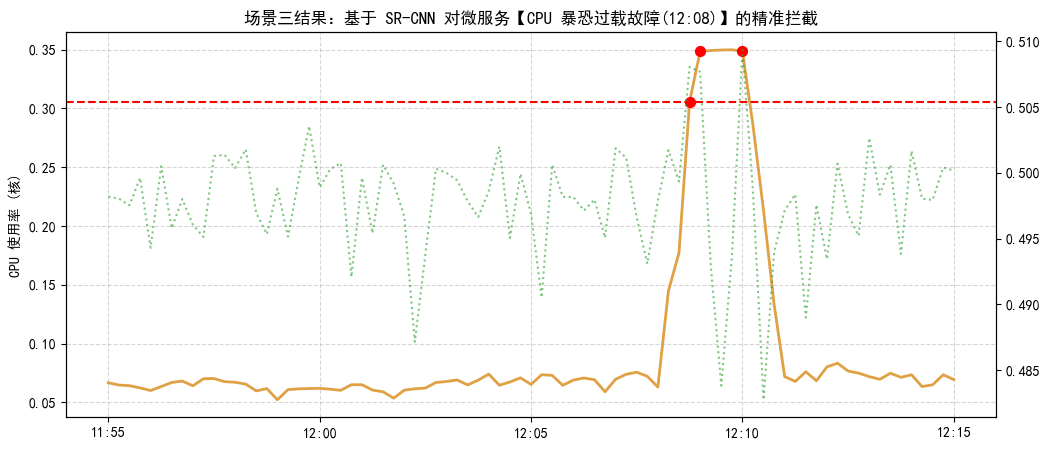

In [20]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

class SRCNN(nn.Module):
    def __init__(self, window_size=64):
        super(SRCNN, self).__init__()
        self.window_size = window_size
        self.conv = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=3, padding=1)
        )
    def forward(self, x): return self.conv(x)

def compute_spectral_residual(values):
    epsilon = 1e-8
    trans = np.fft.fft(values)
    mag = np.abs(trans)
    mag[mag == 0] = epsilon
    log_mag = np.log(mag)
    filter_size = 5
    kernel = np.ones(filter_size) / filter_size
    padded_log_mag = np.pad(log_mag, filter_size//2, mode='reflect')
    log_mag_smooth = np.convolve(padded_log_mag, kernel, mode='valid')
    spectral_residual = log_mag - log_mag_smooth
    trans.real = np.exp(spectral_residual) * np.cos(np.angle(trans))
    trans.imag = np.exp(spectral_residual) * np.sin(np.angle(trans))
    return np.abs(np.fft.ifft(trans))

print("🔍 [场景三] 正在对【12:08 CPU Stress 算力核弹】进行场景级拦截...")
df = pd.read_csv('sock_shop_test_faults.csv').iloc[168:].copy() # 11:55 -> 12:15
cpu_values = df['cpu_usage'].values
base_time = np.datetime64("2026-05-30 11:55:00")
timestamps = [base_time + np.timedelta64(15 * i, 's') for i in range(len(cpu_values))]

sr_score = compute_spectral_residual(cpu_values)
model = SRCNN(window_size=64)
model.load_state_dict(torch.load('srcnn_sockshop_model_v2.pth'))
model.eval()

cnn_scores = np.zeros_like(sr_score)
with torch.no_grad():
    for i in range(len(sr_score)):
        input_tensor = torch.tensor(np.pad(sr_score[:i+1], (64 - (i+1), 0), mode='edge') if i < 64 else sr_score[i-63:i+1], dtype=torch.float32).view(1, 1, -1)
        cnn_scores[i] = torch.sigmoid(model(input_tensor)[0, 0, -1]).item()

threshold = np.mean(cnn_scores) + 1.75 * np.std(cnn_scores)
anomalies = cnn_scores > threshold

plt.figure(figsize=(12, 5))
plt.rcParams['font.sans-serif'], plt.rcParams['axes.unicode_minus'] = ['SimHei'], False
plt.plot(timestamps, cpu_values, label='原始 CPU 使用率', color='#dfa143', linewidth=2)
plt.scatter(np.array(timestamps)[anomalies], cpu_values[anomalies], color='red', label='SR-CNN 锁定算力过载', s=50, zorder=5)
plt.title('场景三结果：基于 SR-CNN 对微服务【CPU 暴恐过载故障(12:08)】的精准拦截')
plt.ylabel('CPU 使用率 (核)')
plt.grid(True, linestyle='--', alpha=0.5)
ax2 = plt.twinx()
ax2.plot(timestamps, cnn_scores, color='#2ca02c', linestyle=':', alpha=0.6, label='AI 置信度')
ax2.axhline(y=threshold, color='r', linestyle='--')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.savefig('result_scene_3_cpustress.png', dpi=300, bbox_inches='tight')
print(f"🎉 场景三成功捕获了 {np.sum(anomalies)} 个异常点，图表已导出！")